# Hospital Length-of-Stay Prediction
**CSE271 — Data Science Methodology | Spring 2026**  
**Egypt University of Informatics**

---
### Project Goal
Predict how long a patient will stay in hospital using clinical data.

| Task | Target | Metric |
|------|--------|--------|
| **Regression** | Exact days (continuous) | R², RMSE, MAE |
| **Classification** | Risk class: Short / Medium / Long | Accuracy, F1, Long-stay Recall |


### Dataset
Microsoft Hospital LOS Dataset — [Kaggle Link](https://www.kaggle.com/datasets/aayushchou/hospital-length-of-stay-dataset-microsoft)  
Download `LengthOfStay.csv` and place it in the same folder as this notebook.


---
## Step 0 — Install & Import Libraries

In [66]:
# Uncomment to install if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# ── Preprocessing & Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ── Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ── Metrics
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
COLORS = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED']

# ── Constants
TARGET      = 'lengthofstay'
DROP_COLS   = ['eid', 'vdate', 'discharged', 'facid']
CLASS_LABELS = {0: CLASS_LABELS[0], 1: CLASS_LABELS[1], 2: 'Long (8+d)'}
MODELS_DIR  = Path('saved_models')
PLOTS_DIR   = Path('plots')
MODELS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 1 — Load & Inspect the Dataset

In [67]:
df = pd.read_csv('LengthOfStay.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 100,000 rows × 28 columns


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [68]:
print('Column data types:')
print(df.dtypes)

print('\nMissing values per column:')
print(df.isnull().sum())


Column data types:
eid                             int64
vdate                          object
rcount                         object
gender                         object
dialysisrenalendstage           int64
asthma                          int64
irondef                         int64
pneum                           int64
substancedependence             int64
psychologicaldisordermajor      int64
depress                         int64
psychother                      int64
fibrosisandother                int64
malnutrition                    int64
hemo                            int64
hematocrit                    float64
neutrophils                   float64
sodium                        float64
glucose                       float64
bloodureanitro                float64
creatinine                    float64
bmi                           float64
pulse                           int64
respiration                   float64
secondarydiagnosisnonicd9       int64
discharged                     

In [69]:
print('Target variable (lengthofstay) statistics:')
print(df[TARGET].describe())

Target variable (lengthofstay) statistics:
count    100000.00000
mean          4.00103
std           2.36031
min           1.00000
25%           2.00000
50%           4.00000
75%           6.00000
max          17.00000
Name: lengthofstay, dtype: float64


---
## Step 2 — Exploratory Data Analysis (EDA)

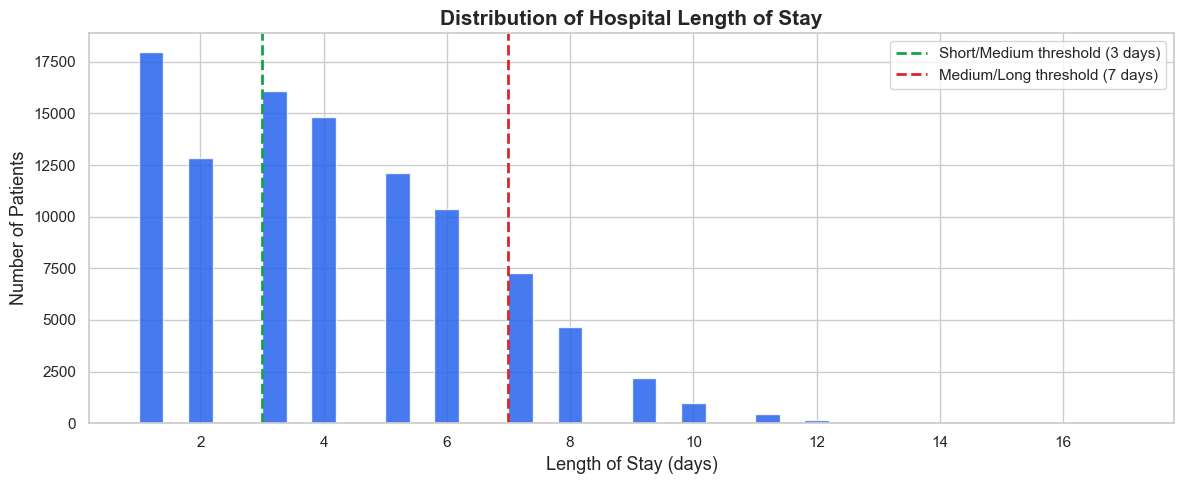

So What? Most patients have short stays (0-3 days). Long-stay patients are fewer
   but consume disproportionate bed-days — making them the key prediction target.


In [70]:
# ── Plot 1: LOS Distribution
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df[TARGET], bins=40, color='#2563EB', edgecolor='white', alpha=0.85)
ax.axvline(3, color='#16A34A', linestyle='--', lw=2, label='Short/Medium threshold (3 days)')
ax.axvline(7, color='#DC2626', linestyle='--', lw=2, label='Medium/Long threshold (7 days)')
ax.set_xlabel('Length of Stay (days)', fontsize=13)
ax.set_ylabel('Number of Patients', fontsize=13)
ax.set_title('Distribution of Hospital Length of Stay', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot_01_los_distribution.png', dpi=150)
plt.show()
print('So What? Most patients have short stays (0-3 days). Long-stay patients are fewer')
print('   but consume disproportionate bed-days — making them the key prediction target.')

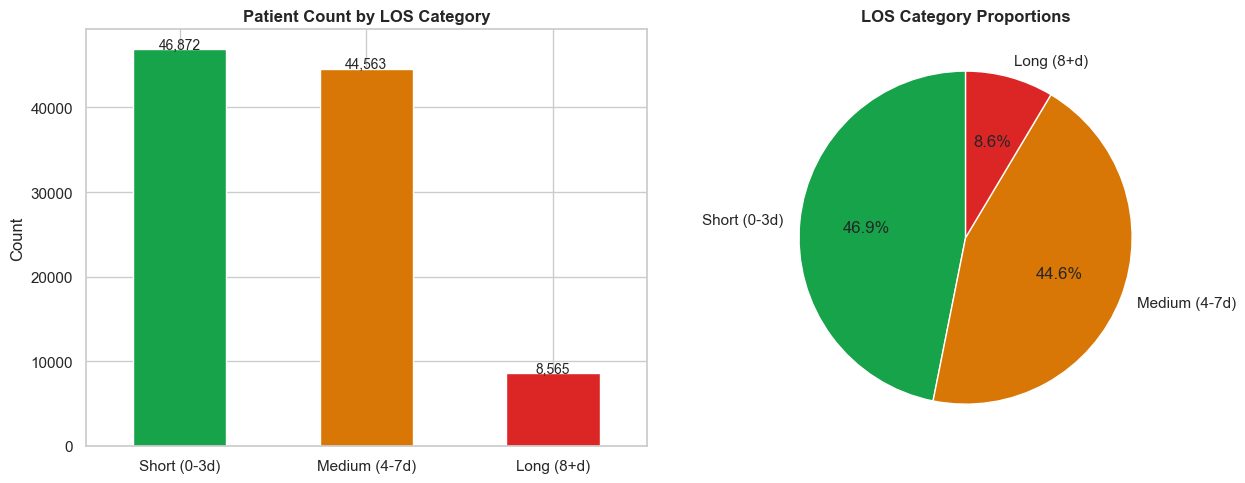

In [71]:
# ── Plot 2: LOS Category Breakdown
def categorize_los(days):
    if days <= 3:   return CLASS_LABELS[0]
    elif days <= 7: return CLASS_LABELS[1]
    else:           return CLASS_LABELS[2]

los_cat = df[TARGET].apply(categorize_los)
cat_counts = los_cat.value_counts().reindex(CLASS_LABELS.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cat_counts.plot(kind='bar', ax=axes[0],
                color=['#16A34A', '#D97706', '#DC2626'], edgecolor='white')
axes[0].set_title('Patient Count by LOS Category', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(cat_counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(cat_counts, labels=cat_counts.index,
            colors=['#16A34A', '#D97706', '#DC2626'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('LOS Category Proportions', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_category_breakdown.png', dpi=150)
plt.show()

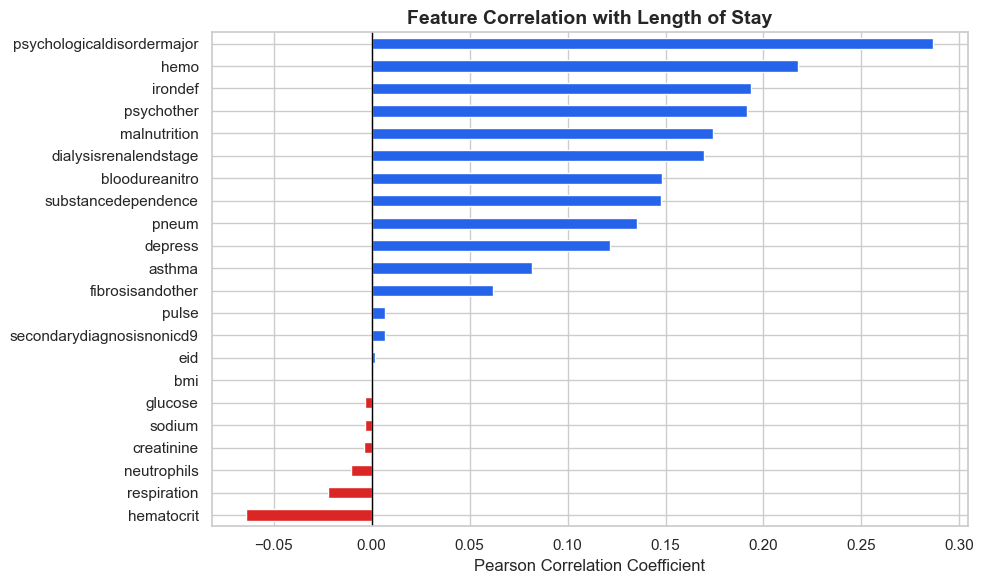

  So What? Features with high positive correlation increase LOS.
   These are the most clinically relevant admission-day risk factors.


In [72]:
# ── Plot 3: Numeric correlations with LOS
numeric_df = df.select_dtypes(include=np.number)
corr_with_los = numeric_df.corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DC2626' if v < 0 else '#2563EB' for v in corr_with_los]
corr_with_los.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_title('Feature Correlation with Length of Stay', fontweight='bold', fontsize=14)
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('plot_03_correlations.png', dpi=150)
plt.show()
print('  So What? Features with high positive correlation increase LOS.')
print('   These are the most clinically relevant admission-day risk factors.')

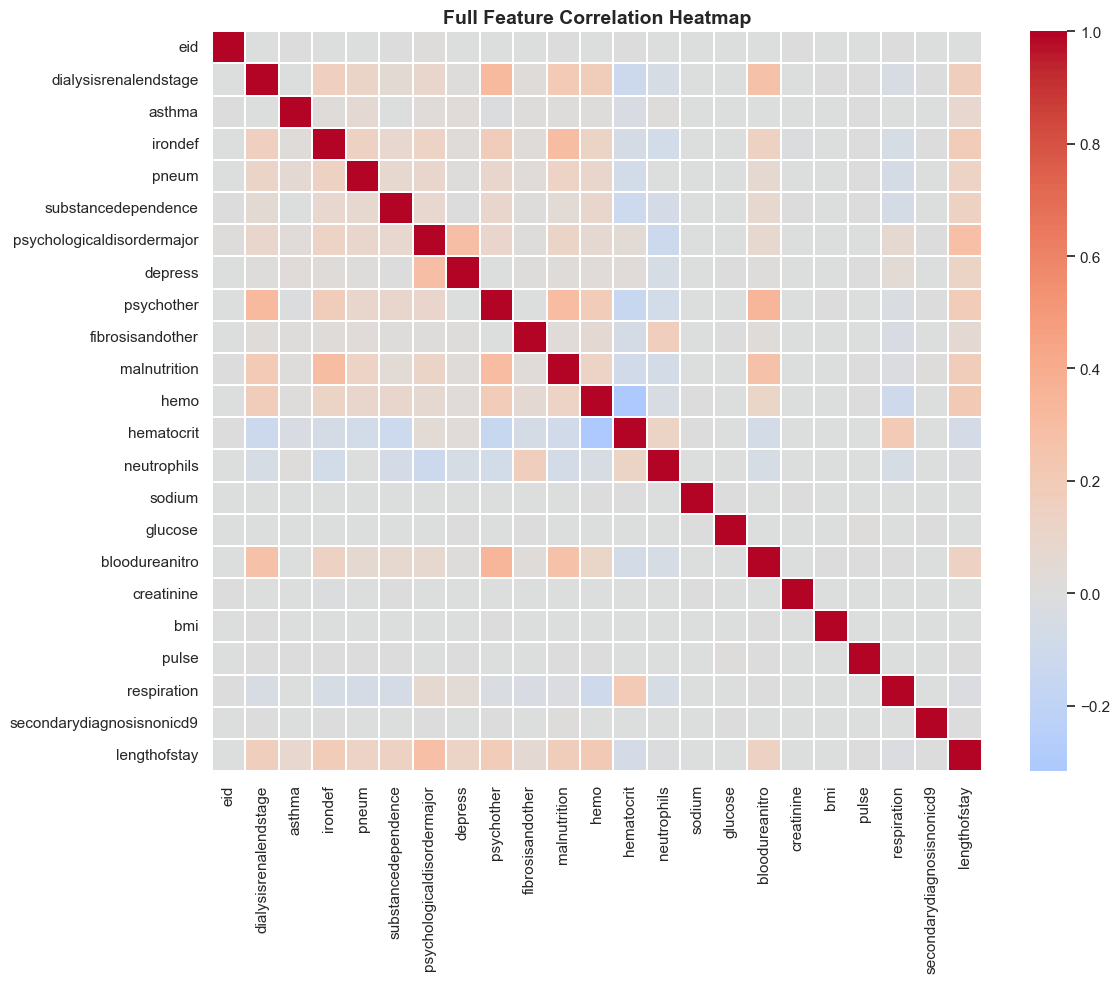

In [ ]:
# ── Plot 4: Full correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', center=0,
            ax=ax, linewidths=0.3)
ax.set_title('Full Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig( 'plot_04_heatmap.png', dpi=150)
plt.show()

---
##  Step 3 — Feature Preparation & Train/Test Split

> ** No leakage:** We do NOT scale or impute before splitting.
> Each model wraps its own `ColumnTransformer` inside a `Pipeline` that is fitted only on `X_train`.

In [74]:
# ── Drop leakage / ID columns
# 'discharged' leaks the answer (it contains the discharge date)
data = df.drop(columns=[c for c in DROP_COLS if c in df.columns]).copy()
print(f'Dropped leakage columns: {[c for c in DROP_COLS if c in df.columns]}')

# ── Define targets
y_reg = data[TARGET].copy()                  # Regression: continuous days
y_clf = y_reg.apply(lambda d: 0 if d <= 3 else (1 if d <= 7 else 2))  # Classification: 0/1/2

X = data.drop(columns=[TARGET])
print(f'\nFeatures: {X.shape[1]}  |  Samples: {X.shape[0]:,}')
print(f'Class distribution:\n{y_clf.value_counts().rename(CLASS_LABELS)}')

# ── Stratified train/test split (80/20)
# stratify=y_clf ensures each class is proportionally represented in both sets
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f'\nTrain size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}')

Dropped leakage columns: ['eid', 'vdate', 'discharged', 'facid']

Features: 23  |  Samples: 100,000
Class distribution:
lengthofstay
Short (0-3d)     46872
Medium (4-7d)    44563
Long (8+d)        8565
Name: count, dtype: int64

Train size: 80,000  |  Test size: 20,000


In [75]:
# ── Leak-safe preprocessor factory
# Returns a ColumnTransformer that handles numeric and categorical columns separately.
# This is built fresh for each pipeline so it is ALWAYS fitted only on training data.

def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer(transformers=[
        ('num', numeric_pipeline,     num_cols),
        ('cat', categorical_pipeline, cat_cols),
    ])

def make_pipeline(estimator):
    """Wrap an estimator in a leak-safe preprocessing pipeline."""
    return Pipeline([
        ('preprocess', build_preprocessor(X_train)),
        ('model',      estimator),
    ])

print('Pipeline factory ready.')

Pipeline factory ready.


---
## Step 4 — Regression Models
**MUST:** Linear Regression, Decision Tree  
**BONUS ★:** Random Forest, XGBoost

In [76]:
def eval_regressor(name, pipeline):
    pipeline.fit(X_train, yr_train)
    preds = pipeline.predict(X_test)
    r2   = r2_score(yr_test, preds)
    rmse = float(np.sqrt(mean_squared_error(yr_test, preds)))
    mae  = mean_absolute_error(yr_test, preds)
    verdict = ('Strong enough for bed-capacity planning.' if r2 >= 0.75
               else 'Useful as a baseline, but not enough for individual planning.')
    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n{name}')
    print(f'  R²   = {r2:.4f}')
    print(f'  RMSE = {rmse:.4f} days')
    print(f'  MAE  = {mae:.4f} days')
    print(f'    {verdict}\n')
    return pipeline, preds, {'R2': r2, 'RMSE': rmse, 'MAE': mae}

In [77]:
# ── MUST ①: Linear Regression
lr_pipe, lr_preds, lr_scores = eval_regressor(
    'MUST ① Linear Regression',
    make_pipeline(LinearRegression())
)
print('  So What? Linear Regression gives a globally interpretable baseline.')
print(f' It explains {lr_scores["R2"]*100:.1f}% of LOS variance using a simple linear combination of features.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MUST ① Linear Regression
  R²   = 0.7495
  RMSE = 1.1862 days
  MAE  = 0.8975 days
    Useful as a baseline, but not enough for individual planning.

  So What? Linear Regression gives a globally interpretable baseline.
 It explains 74.9% of LOS variance using a simple linear combination of features.


In [78]:
# ── MUST ②: Decision Tree Regressor
dt_pipe, dt_preds, dt_scores = eval_regressor(
    'MUST ② Decision Tree Regressor',
    make_pipeline(DecisionTreeRegressor(max_depth=8, random_state=42))
)
print('  So What? Decision Tree captures non-linear interactions (e.g., ICU + age).')
print('   It is interpretable — a doctor can follow the decision path to understand')
print('   why the model predicted a long stay.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MUST ② Decision Tree Regressor
  R²   = 0.7941
  RMSE = 1.0752 days
  MAE  = 0.8251 days
    Strong enough for bed-capacity planning.

  So What? Decision Tree captures non-linear interactions (e.g., ICU + age).
   It is interpretable — a doctor can follow the decision path to understand
   why the model predicted a long stay.


In [79]:
# ── BONUS ★: Random Forest Regressor
rf_pipe, rf_preds, rf_scores = eval_regressor(
    'BONUS ★ Random Forest Regressor',
    make_pipeline(RandomForestRegressor(
        n_estimators=120, max_depth=18, min_samples_leaf=2, n_jobs=1, random_state=42
    ))
)
print('  So What? Ensemble of trees reduces overfitting vs a single Decision Tree.')
print(f'   RMSE improvement of {dt_scores["RMSE"] - rf_scores["RMSE"]:.2f} days over Decision Tree.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BONUS ★ Random Forest Regressor
  R²   = 0.9122
  RMSE = 0.7023 days
  MAE  = 0.4913 days
    Strong enough for bed-capacity planning.

  So What? Ensemble of trees reduces overfitting vs a single Decision Tree.
   RMSE improvement of 0.37 days over Decision Tree.


In [80]:
# ── BONUS ★: XGBoost Regressor
xgb_pipe, xgb_preds, xgb_scores = eval_regressor(
    'BONUS ★ XGBoost Regressor',
    make_pipeline(xgb.XGBRegressor(
        n_estimators=180, max_depth=5, learning_rate=0.08,
        subsample=0.9, colsample_bytree=0.9,
        objective='reg:squarederror', n_jobs=1, random_state=42, verbosity=0
    ))
)
print('  So What? XGBoost is the state-of-the-art benchmark for tabular clinical data.')
print('   Its gradient boosting framework handles missing values and outliers natively.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BONUS ★ XGBoost Regressor
  R²   = 0.9611
  RMSE = 0.4673 days
  MAE  = 0.3535 days
    Strong enough for bed-capacity planning.

  So What? XGBoost is the state-of-the-art benchmark for tabular clinical data.
   Its gradient boosting framework handles missing values and outliers natively.


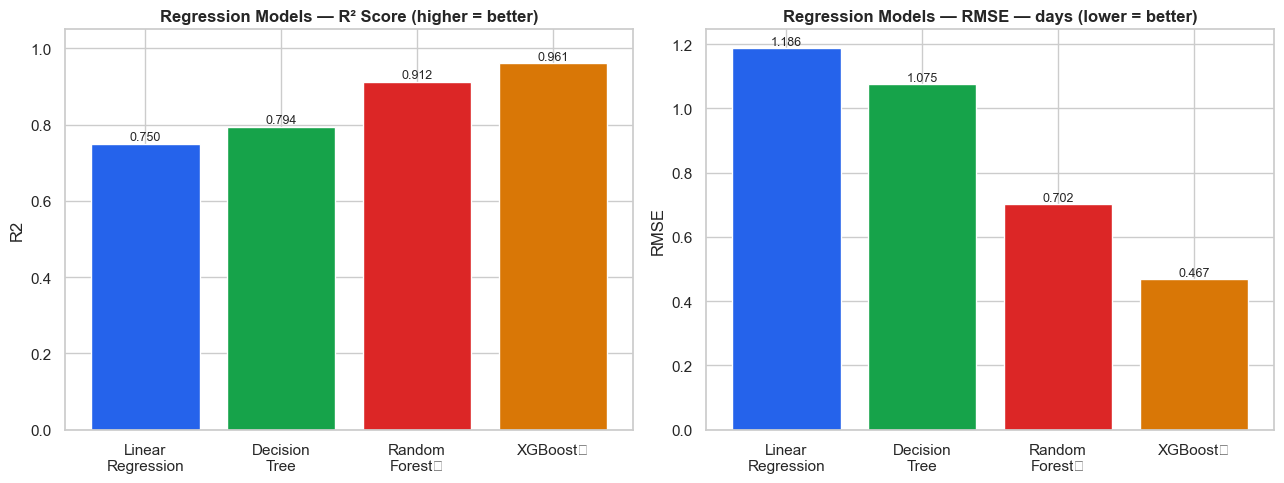

In [ ]:
# ── Plot 5: Regression model comparison
reg_df = reg_summary.reset_index().rename(columns={'index': 'Model'})
short_names = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest★', 'XGBoost★']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title, better in [
    (axes[0], 'R2',   'R² Score (higher = better)', 'high'),
    (axes[1], 'RMSE', 'RMSE — days (lower = better)', 'low'),
]:
    bars = ax.bar(short_names, reg_df[col], color=COLORS[:4], edgecolor='white')
    ax.set_title(f'Regression Models — {title}', fontweight='bold')
    ax.set_ylabel(col)
    if col == 'R2': ax.set_ylim(0, 1.05)
    for bar, val in zip(bars, reg_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig( 'plot_05_regression_comparison.png', dpi=150)
plt.show()

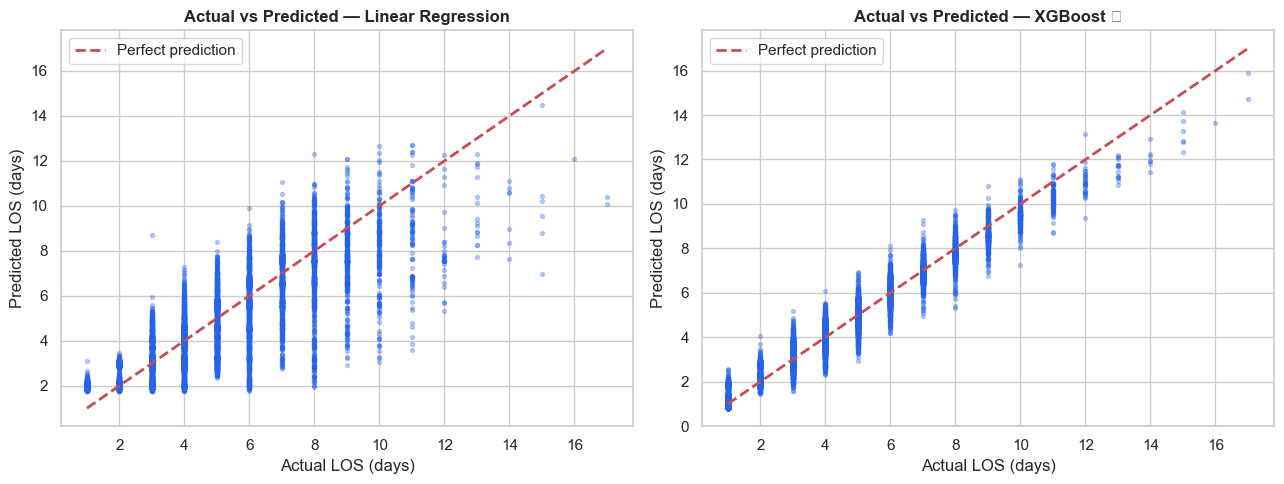

In [ ]:
# ── Plot 6: Actual vs Predicted (Linear Regression vs XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, name in [
    (axes[0], lr_preds,  'Linear Regression'),
    (axes[1], xgb_preds, 'XGBoost ★'),
]:
    ax.scatter(yr_test, preds, alpha=0.3, s=8, color='#2563EB')
    ax.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()],
            'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual LOS (days)')
    ax.set_ylabel('Predicted LOS (days)')
    ax.set_title(f'Actual vs Predicted — {name}', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig( 'plot_06_actual_vs_predicted.png', dpi=150)
plt.show()

---
## Step 5 — Classification Models
**MUST:** Logistic Regression, KNN  
**BONUS ★:** Linear SVM, Random Forest Classifier, Neural Network (MLP)

> **Note:** `class_weight='balanced'` is applied on SVM and Random Forest to handle class imbalance.

In [84]:
target_names = [CLASS_LABELS[i] for i in sorted(CLASS_LABELS)]

def eval_classifier(name, pipeline):
    pipeline.fit(X_train, yc_train)
    preds = pipeline.predict(X_test)
    acc   = accuracy_score(yc_test, preds)
    prec  = precision_score(yc_test, preds, average='weighted', zero_division=0)
    rec   = recall_score(yc_test, preds, average='weighted', zero_division=0)
    f1    = f1_score(yc_test, preds, average='weighted', zero_division=0)
    # Long-stay recall: how well we catch the critical Long (8+d) patients
    long_recall = recall_score(yc_test == 2, preds == 2, zero_division=0)
    cm    = confusion_matrix(yc_test, preds, labels=[0, 1, 2])

    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n{name}')
    print(f'  Accuracy         = {acc:.4f}')
    print(f'  Precision        = {prec:.4f}')
    print(f'  Recall           = {rec:.4f}')
    print(f'  F1-Score         = {f1:.4f}')
    print(f'  Long-stay Recall = {long_recall:.4f}  ← fraction of Long patients correctly flagged')
    print(classification_report(yc_test, preds, target_names=target_names, zero_division=0))

    return pipeline, preds, cm, {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1': f1, 'LongStayRecall': long_recall,
    }

In [85]:
# ── MUST: Logistic Regression
log_pipe, log_preds, log_cm, log_scores = eval_classifier(
    'MUST: Logistic Regression',
    make_pipeline(LogisticRegression(max_iter=1200, random_state=42))
)
print('  So What? Logistic Regression gives calibrated class probabilities.')
print('   A patient with 85% predicted probability of Long stay triggers early')
print('   social work referral and discharge planning on Day 1.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MUST: Logistic Regression
  Accuracy         = 0.8027
  Precision        = 0.7998
  Recall           = 0.8027
  F1-Score         = 0.7979
  Long-stay Recall = 0.5137  ← fraction of Long patients correctly flagged
               precision    recall  f1-score   support

 Short (0-3d)       0.81      0.93      0.87      9374
Medium (4-7d)       0.82      0.73      0.77      8913
   Long (8+d)       0.64      0.51      0.57      1713

     accuracy                           0.80     20000
    macro avg       0.76      0.72      0.74     20000
 weighted avg       0.80      0.80      0.80     20000

  So What? Logistic Regression gives calibrated class probabilities.
   A patient with 85% predicted probability of Long stay triggers early
   social work referral and discharge planning on Day 1.


In [86]:
# ── MUST: K-Nearest Neighbors
knn_pipe, knn_preds, knn_cm, knn_scores = eval_classifier(
    'MUST: K-Nearest Neighbors (k=7)',
    make_pipeline(KNeighborsClassifier(n_neighbors=7))
)
print('  So What? KNN finds the 7 most similar past patients and uses their LOS category.')
print('   Sensitive to feature scaling — handled leak-safely inside the pipeline.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MUST: K-Nearest Neighbors (k=7)
  Accuracy         = 0.7977
  Precision        = 0.7923
  Recall           = 0.7977
  F1-Score         = 0.7713
  Long-stay Recall = 0.1022  ← fraction of Long patients correctly flagged
               precision    recall  f1-score   support

 Short (0-3d)       0.79      0.96      0.87      9374
Medium (4-7d)       0.81      0.76      0.78      8913
   Long (8+d)       0.71      0.10      0.18      1713

     accuracy                           0.80     20000
    macro avg       0.77      0.61      0.61     20000
 weighted avg       0.79      0.80      0.77     20000

  So What? KNN finds the 7 most similar past patients and uses their LOS category.
   Sensitive to feature scaling — handled leak-safely inside the pipeline.


In [87]:
# ── BONUS ★: Linear SVM
# class_weight='balanced' adjusts for the unequal Short/Medium/Long class sizes
svm_pipe, svm_preds, svm_cm, svm_scores = eval_classifier(
    'BONUS ★ Linear SVM',
    make_pipeline(LinearSVC(class_weight='balanced', max_iter=4000, random_state=42))
)
print('  So What? Linear SVM finds a maximum-margin decision boundary between classes.')
print('   class_weight=balanced boosts sensitivity to the minority Long-stay class.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BONUS ★ Linear SVM
  Accuracy         = 0.7736
  Precision        = 0.7845
  Recall           = 0.7736
  F1-Score         = 0.7701
  Long-stay Recall = 0.5995  ← fraction of Long patients correctly flagged
               precision    recall  f1-score   support

 Short (0-3d)       0.80      0.94      0.87      9374
Medium (4-7d)       0.83      0.63      0.72      8913
   Long (8+d)       0.46      0.60      0.52      1713

     accuracy                           0.77     20000
    macro avg       0.70      0.72      0.70     20000
 weighted avg       0.78      0.77      0.77     20000

  So What? Linear SVM finds a maximum-margin decision boundary between classes.
   class_weight=balanced boosts sensitivity to the minority Long-stay class.


In [88]:
# ── BONUS ★: Random Forest Classifier
rfc_pipe, rfc_preds, rfc_cm, rfc_scores = eval_classifier(
    'BONUS ★ Random Forest Classifier',
    make_pipeline(RandomForestClassifier(
        n_estimators=140, max_depth=18, min_samples_leaf=2,
        class_weight='balanced', n_jobs=1, random_state=42
    ))
)
print('  So What? Random Forest aggregates 140 decision trees, reducing variance.')
print('   It also produces feature importances — valuable for clinical insight.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BONUS ★ Random Forest Classifier
  Accuracy         = 0.8893
  Precision        = 0.8896
  Recall           = 0.8893
  F1-Score         = 0.8881
  Long-stay Recall = 0.7239  ← fraction of Long patients correctly flagged
               precision    recall  f1-score   support

 Short (0-3d)       0.90      0.97      0.93      9374
Medium (4-7d)       0.91      0.84      0.87      8913
   Long (8+d)       0.73      0.72      0.73      1713

     accuracy                           0.89     20000
    macro avg       0.85      0.84      0.84     20000
 weighted avg       0.89      0.89      0.89     20000

  So What? Random Forest aggregates 140 decision trees, reducing variance.
   It also produces feature importances — valuable for clinical insight.


In [89]:
# ── BONUS ★: Neural Network (MLP)
nn_pipe, nn_preds, nn_cm, nn_scores = eval_classifier(
    'BONUS ★ Neural Network (MLP)',
    make_pipeline(MLPClassifier(
        hidden_layer_sizes=(64, 32), early_stopping=True,
        max_iter=180, random_state=42
    ))
)
print('  So What? MLP learns hierarchical feature combinations automatically.')
print('   early_stopping prevents overfitting. Performance vs SVM justifies whether')
print('   complexity is worth the loss of interpretability in a clinical setting.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BONUS ★ Neural Network (MLP)
  Accuracy         = 0.8946
  Precision        = 0.8940
  Recall           = 0.8946
  F1-Score         = 0.8940
  Long-stay Recall = 0.7221  ← fraction of Long patients correctly flagged
               precision    recall  f1-score   support

 Short (0-3d)       0.93      0.93      0.93      9374
Medium (4-7d)       0.87      0.89      0.88      8913
   Long (8+d)       0.82      0.72      0.77      1713

     accuracy                           0.89     20000
    macro avg       0.87      0.85      0.86     20000
 weighted avg       0.89      0.89      0.89     20000

  So What? MLP learns hierarchical feature combinations automatically.
   early_stopping prevents overfitting. Performance vs SVM justifies whether
   complexity is worth the loss of interpretability in a clinical setting.


In [90]:
# ── Classification Summary Table
clf_results = {
    'Logistic Regression (MUST)': log_scores,
    'KNN (MUST)':                  knn_scores,
    'Linear SVM ★':                svm_scores,
    'Random Forest Clf ★':         rfc_scores,
    'Neural Network ★':            nn_scores,
}
clf_summary = pd.DataFrame(clf_results).T.round(4)
print('\nCLASSIFICATION SUMMARY')
display(clf_summary)

best_clf_name = clf_summary['F1'].idxmax()
print(f'\nBest classification model (by F1): {best_clf_name}')


CLASSIFICATION SUMMARY


,Accuracy,Precision,Recall,F1,LongStayRecall
Logistic Regression (MUST),0.8027,0.7998,0.8027,0.7979,0.5137
KNN (MUST),0.7977,0.7923,0.7977,0.7713,0.1022
Linear SVM ★,0.7736,0.7845,0.7736,0.7701,0.5995
Random Forest Clf ★,0.8893,0.8896,0.8893,0.8881,0.7239
Neural Network ★,0.8946,0.8940,0.8946,0.8940,0.7221



Best classification model (by F1): Neural Network ★


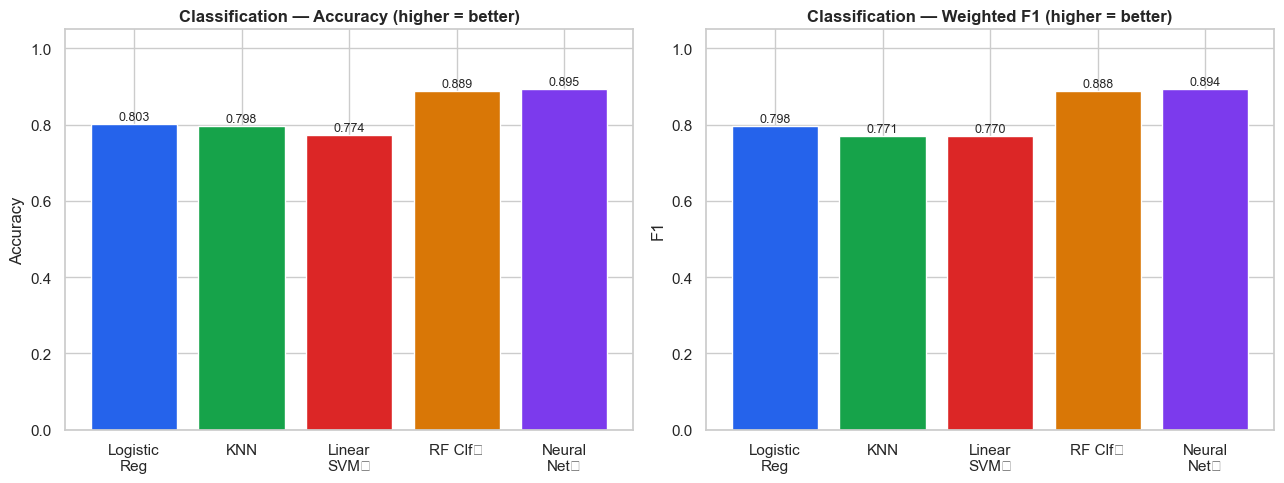

In [ ]:
# ── Plot 7: Classification model comparison
short_clf_names = ['Logistic\nReg', 'KNN', 'Linear\nSVM★', 'RF Clf★', 'Neural\nNet★']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], 'Accuracy', 'Accuracy (higher = better)'),
    (axes[1], 'F1',       'Weighted F1 (higher = better)'),
]:
    vals = clf_summary[col].values
    bars = ax.bar(short_clf_names, vals, color=COLORS[:5], edgecolor='white')
    ax.set_title(f'Classification — {title}', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(col)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig( 'plot_07_classification_comparison.png', dpi=150)
plt.show()

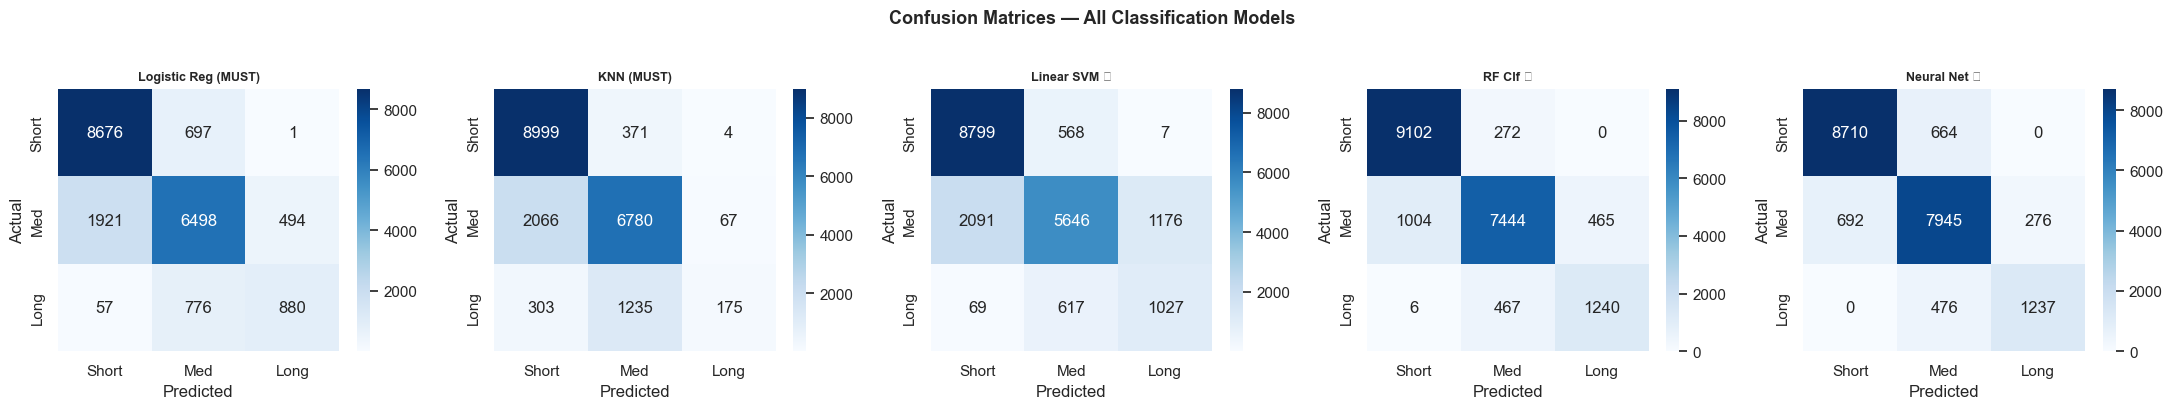

  So What? Off-diagonal cells = misclassifications.
   Short→Long errors waste beds. Long→Short errors cause premature discharge.


In [ ]:
# ── Plot 8: Confusion matrices (all 5 classifiers)
all_cms   = [log_cm,   knn_cm,   svm_cm,    rfc_cm,          nn_cm]
all_names = ['Logistic Reg (MUST)', 'KNN (MUST)', 'Linear SVM ★', 'RF Clf ★', 'Neural Net ★']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, cm, name in zip(axes, all_cms, all_names):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Short', 'Med', 'Long'],
                yticklabels=['Short', 'Med', 'Long'])
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Classification Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig( 'plot_08_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('  So What? Off-diagonal cells = misclassifications.')
print('   Short→Long errors waste beds. Long→Short errors cause premature discharge.')

---
## Step 6 — Feature Importance

We extract importance from the best regression model (tree-based: `feature_importances_`; linear: `|coef_|`).

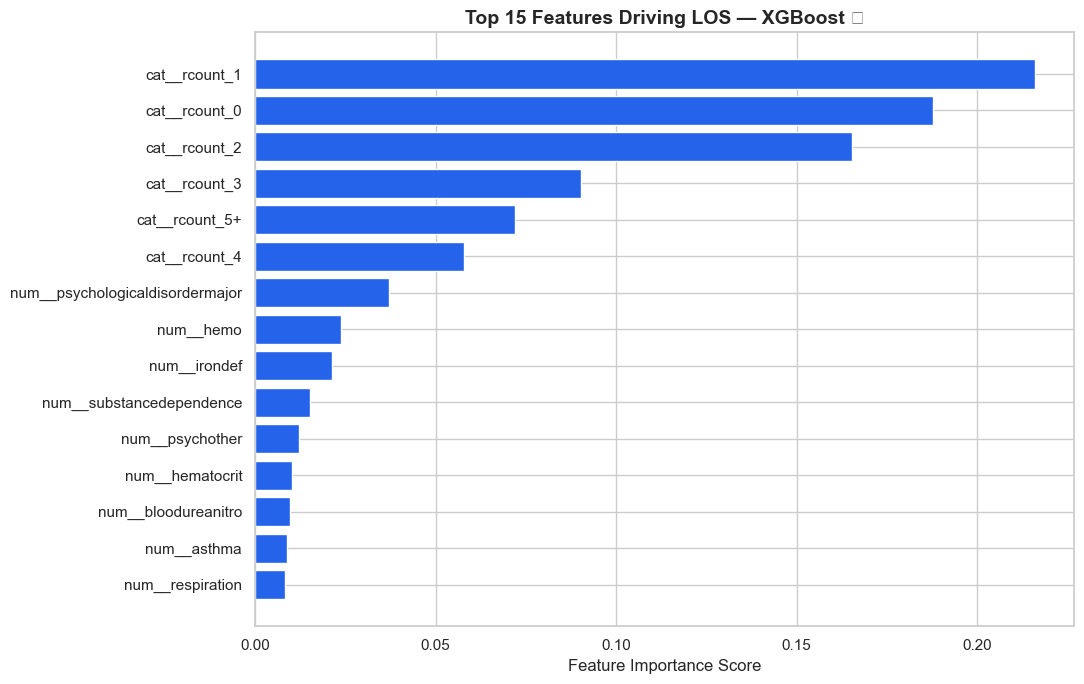

Top 5 most important features:
  cat__rcount_1: 0.2161
  cat__rcount_0: 0.1878
  cat__rcount_2: 0.1655
  cat__rcount_3: 0.0901
  cat__rcount_5+: 0.0721

  So What? These top features are the clinical factors that most determine LOS.
   Hospitals can create a rapid 5-question admission screen using these variables
   to flag high-risk patients on Day 1 for early discharge planning.


In [ ]:
# ── Pick best regression pipeline
reg_pipe_map = {
    'Linear Regression (MUST)': lr_pipe,
    'Decision Tree (MUST)':     dt_pipe,
    'Random Forest ★':          rf_pipe,
    'XGBoost ★':                xgb_pipe,
}
best_reg_pipe = reg_pipe_map[best_reg_name]

# ── Get feature names from the fitted preprocessor
feature_names = best_reg_pipe.named_steps['preprocess'].get_feature_names_out().tolist()
estimator     = best_reg_pipe.named_steps['model']

if hasattr(estimator, 'feature_importances_'):
    values = estimator.feature_importances_
elif hasattr(estimator, 'coef_'):
    values = np.abs(estimator.coef_).ravel()
else:
    values = np.zeros(len(feature_names))

feature_importance = (
    pd.DataFrame({'Feature': feature_names, 'Importance': values})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

# ── Plot 9: Top 15 features
top15 = feature_importance.head(15).sort_values('Importance')
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top15['Feature'], top15['Importance'], color='#2563EB', edgecolor='white')
ax.set_title(f'Top 15 Features Driving LOS — {best_reg_name}', fontweight='bold', fontsize=14)
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig( 'plot_09_feature_importance.png', dpi=150)
plt.show()

print('Top 5 most important features:')
for _, row in feature_importance.head(5).iterrows():
    print(f'  {row["Feature"]}: {row["Importance"]:.4f}')

print('\n  So What? These top features are the clinical factors that most determine LOS.')
print('   Hospitals can create a rapid 5-question admission screen using these variables')
print('   to flag high-risk patients on Day 1 for early discharge planning.')

---
## Step 7 — Save Models & Artifacts

In [94]:
# ── Save best pipelines
clf_pipe_map = {
    'Logistic Regression (MUST)': log_pipe,
    'KNN (MUST)':                  knn_pipe,
    'Linear SVM ★':                svm_pipe,
    'Random Forest Clf ★':         rfc_pipe,
    'Neural Network ★':            nn_pipe,
}
best_clf_pipe = clf_pipe_map[best_clf_name]

joblib.dump(best_reg_pipe, MODELS_DIR / 'regression_model.pkl')
joblib.dump(best_clf_pipe, MODELS_DIR / 'classification_model.pkl')

# ── Save metadata
metadata = {
    'feature_columns':          X.columns.tolist(),
    'class_labels':             CLASS_LABELS,
    'best_regression_model':    best_reg_name,
    'best_classification_model': best_clf_name,
}
(MODELS_DIR / 'metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')

# ── Save metrics
metrics = {
    'best_regression_model':    best_reg_name,
    'best_classification_model': best_clf_name,
    'regression':    reg_results,
    'classification': clf_results,
}
(MODELS_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')

# ── Save feature importance
feature_importance.head(25).to_csv(MODELS_DIR / 'top_features.csv', index=False)

print('Saved:')
for f in sorted(MODELS_DIR.iterdir()):
    print(f'   {f}')

Saved:
   saved_models\classification_model.pkl
   saved_models\feature_importance.csv
   saved_models\metadata.json
   saved_models\metrics.json
   saved_models\regression_model.pkl
   saved_models\top_features.csv
   saved_models\y_test_classification.csv
   saved_models\y_test_regression.csv


---
## Step 8 — Final Summary

In [96]:
print('=' * 60)
print('  FINAL PROJECT RESULTS SUMMARY')
print('=' * 60)

print('\n REGRESSION MODELS')
display(reg_summary)

print('\n CLASSIFICATION MODELS')
display(clf_summary)

print(f'\n Best Regression Model:     {best_reg_name}')
print(f' Best Classification Model: {best_clf_name}')

print('\nAll plots saved:')
for f in sorted(PLOTS_DIR.iterdir()):
    print(f'   {f}')

  FINAL PROJECT RESULTS SUMMARY

 REGRESSION MODELS


,R2,RMSE,MAE
Linear Regression (MUST),0.7495,1.1862,0.8975
Decision Tree (MUST),0.7941,1.0752,0.8251
Random Forest ★,0.9122,0.7023,0.4913
XGBoost ★,0.9611,0.4673,0.3535



 CLASSIFICATION MODELS


,Accuracy,Precision,Recall,F1,LongStayRecall
Logistic Regression (MUST),0.8027,0.7998,0.8027,0.7979,0.5137
KNN (MUST),0.7977,0.7923,0.7977,0.7713,0.1022
Linear SVM ★,0.7736,0.7845,0.7736,0.7701,0.5995
Random Forest Clf ★,0.8893,0.8896,0.8893,0.8881,0.7239
Neural Network ★,0.8946,0.8940,0.8946,0.8940,0.7221



 Best Regression Model:     XGBoost ★
 Best Classification Model: Neural Network ★

All plots saved:
   plots\plot_01_los_distribution.png
   plots\plot_02_category_breakdown.png
   plots\plot_03_correlations.png
   plots\plot_04_heatmap.png
   plots\plot_05_regression_comparison.png
   plots\plot_06_actual_vs_predicted.png
   plots\plot_07_classification_comparison.png
   plots\plot_08_confusion_matrices.png
   plots\plot_09_feature_importance.png
